# Perchance — Methodology Walkthrough

This notebook reproduces the project's modeling methodology end-to-end, small-scale,
in about two minutes. It needs **only the Python environment and the checked-in sample
dataset** — no database, no Redis, no Docker, no API keys, no trained model files.

Every pipeline step calls the **real library functions** from
`backend/nba_betting/ml/train_regression.py` (the same module `manage.py train_models`
and `research/walk_forward_eval.py` use) — nothing here is a notebook-only
reimplementation. The narrative assumes a data-science-literate reader.

**What you'll see:**

1. Load two seasons of box scores through the real CSV loader.
2. Build rolling features and *see* the `shift(1)` that keeps game *t* out of its own features.
3. **The leakage demo** — train the same model on deliberately-leaky features and watch the test MAE collapse into fantasy; plus why random splits flatter time-series models.
4. Train the production-style points model and compare it to a no-ML baseline.
5. Turn a projection + line into P(over) — Normal for high-count stats, Poisson for low-count.
6. A backtest-style evaluation for one star player, with the four statistical validation tests.
7. Caveats — the part most modeling write-ups skip.

Full methodology, assumptions, and limitations: [`docs/METHODOLOGY.md`](../docs/METHODOLOGY.md).

In [1]:
import logging
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xgboost as xgb
from scipy.stats import binomtest, spearmanr, ttest_1samp

T0 = time.time()

# Import the REAL training library from backend/ — same pattern as
# research/walk_forward_eval.py. No Django required: these modules are pure
# pandas/numpy/xgboost.
REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / "backend").exists():          # running from notebooks/
    REPO_ROOT = REPO_ROOT.parent
assert (REPO_ROOT / "backend").exists(), "Run from the repo root or notebooks/"
sys.path.insert(0, str(REPO_ROOT / "backend"))

from nba_betting.ml.train_regression import (
    FEATURE_COLUMNS,
    MIN_MINUTES,
    STAT_TARGET,
    VAL_FRAC,
    build_opponent_defense,
    build_player_features,
    eligible_rows,
    load_and_filter_csv,
    time_split,
    train_xgboost_regression,
)

logging.basicConfig(level=logging.INFO, stream=sys.stdout, format="%(message)s")

# Chart chrome (validated reference palette — see the dataviz conventions)
BLUE, RED, YELLOW, AQUA = "#2a78d6", "#e34948", "#eda100", "#1baf7a"
INK, MUTED, GRID = "#0b0b0b", "#898781", "#e1e0d9"
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": GRID, "axes.labelcolor": INK,
    "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "grid.color": GRID, "grid.linewidth": 0.8,
    "font.family": "sans-serif", "font.size": 10,
})

pd.set_option("display.width", 120)
print("xgboost", xgb.__version__, "| pandas", pd.__version__, "| numpy", np.__version__)

xgboost 3.1.3 | pandas 2.3.3 | numpy 2.4.1


## 1. Load the sample through the real loader

`data/sample/PlayerStatistics_sample.csv.gz` is a two-season slice of the full NBA
box-score dump (2023-24 as a warm-up runway + the complete 2024-25 season — see
[`data/sample/README.md`](../data/sample/README.md)). Crucially it keeps **every
player-row of every included game**, because opponent-defense features sum full team
totals — sampling players would silently corrupt them.

`load_and_filter_csv()` accepts a path and pandas reads the `.gz` natively, so the
production loader runs unchanged. It applies the game-type filter, parses dates and
minutes, and derives `is_home` / `fg_pct`. One convention worth noticing: rows with
fewer than `MIN_MINUTES` (=10) minutes are **kept** at this stage — they must occupy
rolling-window slots and count toward team totals — and are only excluded later as
*training targets* via `eligible_rows()`.

In [2]:
SAMPLE = REPO_ROOT / "data" / "sample" / "PlayerStatistics_sample.csv.gz"
df = load_and_filter_csv(str(SAMPLE))

print(f"\n{len(df):,} player-game rows | {df['gameId'].nunique():,} games | "
      f"{df['personId'].nunique():,} players")
print(f"Dates: {df['date'].min().date()} → {df['date'].max().date()}")
df[["firstName", "lastName", "date", "points", "reboundsTotal", "assists",
    "numMinutes", "is_home", "opponentteamName"]].head()

Loading CSV: C:\Users\maxst\Desktop\Projects\nbaPropsPrediction\data\sample\PlayerStatistics_sample.csv.gz


  Raw rows: 68,147


  After filters: 68,147 rows | 709 players | 2023–2025



68,147 player-game rows | 2,566 games | 709 players
Dates: 2023-10-24 → 2025-06-22


,firstName,lastName,date,points,reboundsTotal,assists,numMinutes,is_home,opponentteamName
0,D'Angelo,Russell,2023-10-24,11.0,4.0,7.0,36.0,0,Nuggets
1,Christian,Wood,2023-10-24,7.0,4.0,0.0,15.0,0,Nuggets
2,Jamal,Murray,2023-10-24,21.0,2.0,6.0,34.0,1,Lakers
3,Taurean,Prince,2023-10-24,18.0,3.0,1.0,29.0,0,Nuggets
4,Michael,Porter Jr.,2023-10-24,12.0,12.0,2.0,30.0,1,Lakers


## 2. Feature engineering — and the `shift(1)` that makes it honest

Two real library calls build the entire feature matrix:

- **`build_player_features()`** — per-player rolling means (L5/L10), EMA, rolling std,
  days-rest, expanding season averages, and hot/cold streak ratios. Every rolling
  statistic is computed on `x.shift(1)`, so the window for game *t* ends at game
  *t−1*. Sub-10-minute games are NaN-masked inside the windows (they occupy a slot
  but contribute no value) — the same convention the serving pipeline applies.
- **`build_opponent_defense()`** — for each game, sums what every defending team
  allowed (points/rebounds/assists), then takes a shifted rolling 10-game average
  per team. This is why the sample keeps whole games.

In [3]:
df = build_player_features(df)
df = build_opponent_defense(df)
print(f"Feature matrix: {df.shape[0]:,} rows × {df.shape[1]} columns")
print("Points-model features:", FEATURE_COLUMNS["pts"])

Feature matrix: 68,147 rows × 44 columns
Points-model features: ['is_home', 'days_rest', 'pts_L5', 'pts_L10', 'pts_ema_L5', 'pts_std_L10', 'reb_L5', 'ast_L5', 'min_L5', 'min_L10', 'fg_pct_L5', 'fg_pct_L10', 'season_avg_pts', 'hot_cold_pts', 'opp_pts_allowed_L10']


### Seeing `shift(1)` on a single player

Below are LeBron James's first games in the sample. Read row *t*'s `pts_L5` against
the `points` column above it:

- Game 1 has **no history** → `pts_L5` is NaN (and such rows are dropped before training).
- Game 2's `pts_L5` equals game 1's points, game 3's equals the mean of games 1–2, and so on.
- The **`mean_incl_today`** column is what you'd get *without* `shift(1)` — it contains
  game *t*'s own score. That column is the bug we demonstrate in the next section.

The assertion recomputes `pts_L5` by hand (shift → mask sub-10-minute games → roll)
and requires an exact match with the library output.

In [4]:
lbj = (df[(df["firstName"] == "LeBron") & (df["lastName"] == "James")]
       .sort_values("date").copy())

masked_pts = lbj["points"].where(lbj["numMinutes"] >= MIN_MINUTES)
lbj["mean_prev_5 (manual shift(1))"] = masked_pts.shift(1).rolling(5, min_periods=1).mean()
lbj["mean_incl_today (LEAKY)"] = masked_pts.rolling(5, min_periods=1).mean()

# The library feature must equal the hand-computed shifted mean, row for row.
assert np.allclose(lbj["pts_L5"], lbj["mean_prev_5 (manual shift(1))"], equal_nan=True)
print("OK: pts_L5 == mean of the previous 5 games — game t never sees its own score.\n")

lbj[["date", "points", "pts_L5", "mean_prev_5 (manual shift(1))",
     "mean_incl_today (LEAKY)"]].head(8).reset_index(drop=True)

OK: pts_L5 == mean of the previous 5 games — game t never sees its own score.



,date,points,pts_L5,mean_prev_5 (manual shift(1)),mean_incl_today (LEAKY)
0,2023-10-24,21.0,NaN,NaN,21.0
1,2023-10-26,21.0,21.0,21.0,21.0
2,2023-10-29,27.0,21.0,21.0,23.0
3,2023-10-30,19.0,23.0,23.0,22.0
4,2023-11-01,35.0,22.0,22.0,24.6
5,2023-11-04,24.0,24.6,24.6,25.2
6,2023-11-06,30.0,25.2,25.2,27.0
7,2023-11-08,18.0,27.0,27.0,25.2


## 3. The leakage demo — what happens if you forget `shift(1)`

This is the most instructive experiment in the repo. We rebuild the *same* rolling
features with one change: **no `shift(1)`**. Now `pts_L5` for game *t* is the mean of
games *t−4 … t* — it contains the answer. A 5-game mean that includes today's score
is a very strong "predictor" of today's score, for the useless reason that it *is*
one-fifth of today's score.

At prediction time this feature cannot exist — you don't know tonight's box score
before tip-off — so any metric computed with it describes a model that can never be
deployed. We train identical XGBoost configurations on the honest and the leaky
feature sets, with the **same chronological fit/validation/test split**, and compare
test MAE.

In [5]:
def build_leaky_player_features(d):
    """Deliberately WRONG variant of build_player_features: identical windows,
    identical NaN-masking, but NO shift(1) — game t's own box score leaks into
    game t's features. For demonstration only."""
    d = d.sort_values(["personId", "date"]).reset_index(drop=True)
    masked = d[["points", "reboundsTotal", "assists", "numMinutes", "fg_pct"]].copy()
    masked.loc[~(d["numMinutes"] >= MIN_MINUTES), :] = np.nan
    masked["personId"] = d["personId"]
    grp = masked.groupby("personId", sort=False)

    stat_map = [("points", "pts"), ("reboundsTotal", "reb"), ("assists", "ast"),
                ("numMinutes", "min"), ("fg_pct", "fg_pct")]
    for col, feat in stat_map:
        for w in (5, 10):
            d[f"leaky_{feat}_L{w}"] = grp[col].transform(
                lambda x, w=w: x.rolling(w, min_periods=1).mean())      # ← no .shift(1)
    for col, feat in [("points", "pts"), ("reboundsTotal", "reb"), ("assists", "ast")]:
        d[f"leaky_{feat}_ema_L5"] = grp[col].transform(
            lambda x: x.ewm(span=5, adjust=False).mean())               # ← no .shift(1)
        d[f"leaky_{feat}_std_L10"] = grp[col].transform(
            lambda x: x.rolling(10, min_periods=5).std())               # ← no .shift(1)
    grp_season = d.groupby(["personId", "season_year"], sort=False)
    for col, feat in [("points", "pts"), ("reboundsTotal", "reb"), ("assists", "ast")]:
        d[f"leaky_season_avg_{feat}"] = grp_season[col].transform(
            lambda x: x.expanding(min_periods=1).mean())                # ← no .shift(1)
    for feat in ["pts", "reb", "ast"]:
        sa = d[f"leaky_season_avg_{feat}"]
        d[f"leaky_hot_cold_{feat}"] = (d[f"leaky_{feat}_L5"] - sa) / (sa.abs() + 0.1)
    return d


df = build_leaky_player_features(df)

# The leaky twin of FEATURE_COLUMNS["pts"]: every player-rolling feature swapped
# for its unshifted variant; is_home / days_rest / opponent defense stay honest
# (they contain no same-game information), which isolates the shift(1) effect.
LEAKY_PTS_FEATURES = [
    f"leaky_{c}" if (c not in {"is_home", "days_rest", "opp_pts_allowed_L10"}) else c
    for c in FEATURE_COLUMNS["pts"]
]
print(LEAKY_PTS_FEATURES)

['is_home', 'days_rest', 'leaky_pts_L5', 'leaky_pts_L10', 'leaky_pts_ema_L5', 'leaky_pts_std_L10', 'leaky_reb_L5', 'leaky_ast_L5', 'leaky_min_L5', 'leaky_min_L10', 'leaky_fg_pct_L5', 'leaky_fg_pct_L10', 'leaky_season_avg_pts', 'leaky_hot_cold_pts', 'opp_pts_allowed_L10']


The split below is the library's own convention (`time_split`, used by
`train_all_regression_models`): oldest 80% → training period, newest 20% → test;
the last 15% of the training period (`VAL_FRAC`) is a validation slice used **only**
for early stopping — the test partition takes no part in any selection decision.
`eligible_rows()` restricts *targets* to games with ≥ 10 minutes played.

In [6]:
targets = eligible_rows(df)
train_full, test = time_split(targets)                 # chronological 80 / 20
fit, val = time_split(train_full, test_frac=VAL_FRAC)  # chronological fit / val
print(f"Fit:  {len(fit):>6,} rows  (≤ {fit['date'].max().date()})")
print(f"Val:  {len(val):>6,} rows  (≤ {val['date'].max().date()})")
print(f"Test: {len(test):>6,} rows  (≥ {test['date'].min().date()})")


def fit_eval(fit_df, val_df, test_df, feats, target="points", num_rounds=400):
    """Train via the real train_xgboost_regression() and return (model, metrics,
    test_frame) — test_frame keeps the rows actually scored, for baselines."""
    cols = list(dict.fromkeys(feats + [target]))
    f = fit_df.dropna(subset=cols)
    v = val_df.dropna(subset=cols)
    t = test_df.dropna(subset=cols)
    model, metrics = train_xgboost_regression(
        f[feats].values.astype(np.float32), f[target].values.astype(np.float32),
        v[feats].values.astype(np.float32), v[target].values.astype(np.float32),
        t[feats].values.astype(np.float32), t[target].values.astype(np.float32),
        feats, num_rounds=num_rounds,
    )
    return model, metrics, t

Fit:  30,956 rows  (≤ 2024-12-31)
Val:   5,554 rows  (≤ 2025-02-11)
Test:  9,202 rows  (≥ 2025-02-12)


In [7]:
print("── Honest features (with shift(1)) ──────────────────────────")
_, honest_m, _ = fit_eval(fit, val, test, FEATURE_COLUMNS["pts"])

print("\n── Leaky features (no shift(1)) ─────────────────────────────")
_, leaky_m, _ = fit_eval(fit, val, test, LEAKY_PTS_FEATURES)

honest_mae = honest_m["test"]["mae"]
leaky_mae = leaky_m["test"]["mae"]
print(f"\nHonest test MAE: {honest_mae:.3f} points")
print(f"Leaky  test MAE: {leaky_mae:.3f} points   "
      f"({(1 - leaky_mae / honest_mae) * 100:.0f}% 'better' — and 100% fake)")

── Honest features (with shift(1)) ──────────────────────────


[0]	train-rmse:8.60520	val-rmse:8.47867


[100]	train-rmse:5.92541	val-rmse:6.27383


[143]	train-rmse:5.80709	val-rmse:6.27838



── Leaky features (no shift(1)) ─────────────────────────────
[0]	train-rmse:8.43693	val-rmse:8.31066


[100]	train-rmse:2.94863	val-rmse:3.18102


[200]	train-rmse:2.74141	val-rmse:3.12457


[287]	train-rmse:2.62444	val-rmse:3.12128



Honest test MAE: 5.028 points
Leaky  test MAE: 2.430 points   (52% 'better' — and 100% fake)


The leaky model looks spectacular. It is measuring its ability to *recover an
average it was handed*, not to predict a basketball game. Every point of that gap
is error that would reappear the moment the model faced a real slate.

### Second trap: random splits flatter time-series models

Even with honest features, evaluation design can still flatter. A shuffled
(random) split scatters each player's 2024-25 games across train *and* test, so
the model trains on games played **after** some of its test games — it has seen
the era, the rotations, and each player's in-season trajectory surrounding every
test point, which a deployed model never has. And operationally, deployment is
always forecasting *forward* into a drifting distribution, which only a
chronological split simulates. Same features, same model — only the split changes.

In [8]:
rng = np.random.default_rng(42)
perm = rng.permutation(len(targets))
n_test = int(len(targets) * 0.20)                    # same partition sizes as time_split
n_val = int((len(targets) - n_test) * VAL_FRAC)
r_test = targets.iloc[perm[:n_test]]
r_val = targets.iloc[perm[n_test:n_test + n_val]]
r_fit = targets.iloc[perm[n_test + n_val:]]

print("── Honest features, RANDOM split ────────────────────────────")
_, random_m, _ = fit_eval(r_fit, r_val, r_test, FEATURE_COLUMNS["pts"])
random_mae = random_m["test"]["mae"]

print(f"\nRandom-split  test MAE: {random_mae:.3f}")
print(f"Chronological test MAE: {honest_mae:.3f}   "
      f"(random split flatters by {honest_mae - random_mae:+.3f} MAE)")

── Honest features, RANDOM split ────────────────────────────


[0]	train-rmse:8.54414	val-rmse:8.65147


[100]	train-rmse:5.95645	val-rmse:6.46445


[128]	train-rmse:5.87795	val-rmse:6.46837



Random-split  test MAE: 4.919
Chronological test MAE: 5.028   (random split flatters by +0.110 MAE)


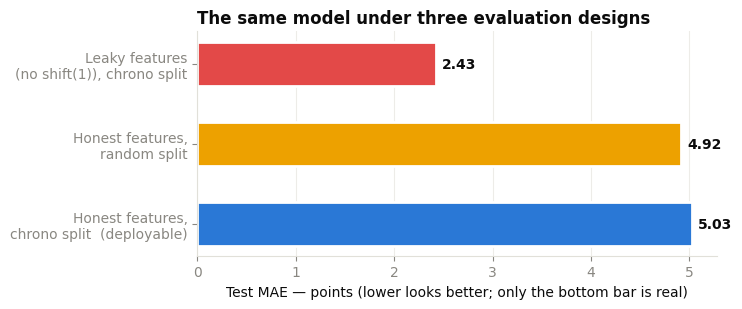

In [9]:
fig, ax = plt.subplots(figsize=(7.5, 3.2))
designs = [
    ("Leaky features\n(no shift(1)), chrono split", leaky_mae, RED),
    ("Honest features,\nrandom split", random_mae, YELLOW),
    ("Honest features,\nchrono split  (deployable)", honest_mae, BLUE),
]
ys = np.arange(len(designs))
for y, (label, v, c) in zip(ys, designs):
    ax.barh(y, v, height=0.55, color=c, edgecolor="white", linewidth=2)
    ax.text(v + 0.06, y, f"{v:.2f}", va="center", color=INK, fontweight="bold")
ax.set_yticks(ys, [d[0] for d in designs])
ax.invert_yaxis()
ax.set_xlabel("Test MAE — points (lower looks better; only the bottom bar is real)")
ax.set_title("The same model under three evaluation designs", loc="left",
             color=INK, fontweight="bold")
ax.grid(axis="x", alpha=0.6)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

## 4. Train the production-style points model, honestly

Now the real thing, exactly as `train_all_regression_models()` does it: honest
features, chronological fit/val/test, early stopping on the validation slice
(up to 1000 rounds, patience 50), targets restricted to ≥ 10-minute games.

The bar that matters is not zero error — points scored in a single NBA game are
genuinely high-variance — but the **naive baseline**: just predict the player's
last-5-game average (`pts_L5`, zero ML). If the model can't beat that on the same
test rows, the machine learning isn't paying rent.

In [10]:
model, final_m, test_frame = fit_eval(
    fit, val, test, FEATURE_COLUMNS["pts"], num_rounds=1000)

naive_mae = float(np.mean(np.abs(test_frame["pts_L5"] - test_frame["points"])))
model_mae = final_m["test"]["mae"]

print(f"\n                    MAE (test, n={len(test_frame):,})")
print(f"Naive L5 baseline :  {naive_mae:.3f} points")
print(f"XGBoost           :  {model_mae:.3f} points")
print(f"Improvement       :  {(1 - model_mae / naive_mae) * 100:.1f}% vs naive")
print(f"\nTrain/Val/Test MAE: {final_m['train']['mae']:.3f} / "
      f"{final_m['val']['mae']:.3f} / {final_m['test']['mae']:.3f}  "
      f"(honest models keep these in the same neighborhood)")

[0]	train-rmse:8.60520	val-rmse:8.47867


[100]	train-rmse:5.92541	val-rmse:6.27383


[143]	train-rmse:5.80709	val-rmse:6.27838



                    MAE (test, n=8,280)
Naive L5 baseline :  5.355 points
XGBoost           :  5.028 points
Improvement       :  6.1% vs naive

Train/Val/Test MAE: 4.645 / 4.892 / 5.028  (honest models keep these in the same neighborhood)


A single-digit-percent improvement over the naive baseline is the honest size of
edge available from box-score features — compare it with the ~60–75% "improvement"
the leaky setup claimed. On the full 2016-present dataset the production run sees
the same ordering (naive > linear > forest ≈ XGBoost in MAE); see
`research/walk_forward_eval.py` for the season-by-season version of this comparison.

## 5. Projection → P(over)

A projection alone doesn't answer the product's question — *how likely is this
player to clear the line?* `nba_betting/services/probability.py::calculate_probability`
is the single source of truth (it imports without Django — `constants.py` is pure
Python):

- **High-count stats (pts, reb)** → Normal, centered on the projection, with the
  player's rolling `std_L10` as dispersion (fallback defaults + a 0.5 floor guard).
- **Low-count stats (ast, stl, blk)** → Poisson, whose variance is tied to the mean —
  no dispersion estimate to get wrong, no continuity correction to miss, and
  `P(X > line)` respects the discreteness of small counts.
- Output is **clamped to [0.01, 0.99]**: with 10-game dispersion windows and no
  injury/lineup information, the model cannot support near-certain claims.

In [11]:
from nba_betting.services.probability import calculate_probability

# Featured player for the rest of the notebook: the star (season avg ≥ 24 pts)
# with the most test-slice games — deterministic, and a household name.
counts = (test_frame.groupby(["firstName", "lastName"])
          .agg(n=("points", "size"), avg=("points", "mean"))
          .query("avg >= 24").sort_values(["n", "avg"], ascending=False))
first, last = counts.index[0]
star = test_frame[(test_frame["firstName"] == first)
                  & (test_frame["lastName"] == last)].sort_values("date").copy()
print(f"Featured player: {first} {last} — {len(star)} test-slice games "
      f"({star['date'].min().date()} → {star['date'].max().date()})\n")

row = star.iloc[-1]
proj = float(model.predict(xgb.DMatrix(
    row[FEATURE_COLUMNS["pts"]].to_frame().T.values.astype(np.float32),
    feature_names=FEATURE_COLUMNS["pts"]))[0])
line = round(float(row["pts_L5"]) * 2) / 2          # synthetic line at 0.5 granularity
std = float(row["pts_std_L10"])

p_over_pts = calculate_probability("pts", proj, line, std)
print(f"{row['firstName']} {row['lastName']} — {row['date'].date()}")
print(f"  PTS  projection {proj:5.1f} vs line {line:4.1f} (σ={std:.2f}, Normal) "
      f"→ P(over) = {p_over_pts:.3f}")

ast_proj = float(row["ast_L5"])                     # naive projection for the demo
ast_line = np.floor(ast_proj) + 0.5
p_over_ast = calculate_probability("ast", ast_proj, ast_line)
print(f"  AST  projection {ast_proj:5.1f} vs line {ast_line:4.1f} (Poisson)      "
      f"→ P(over) = {p_over_ast:.3f}")

Featured player: Shai Gilgeous-Alexander — 48 test-slice games (2025-02-12 → 2025-06-22)



Shai Gilgeous-Alexander — 2025-06-22
  PTS  projection  26.9 vs line 29.0 (σ=8.50, Normal) → P(over) = 0.402
  AST  projection   4.8 vs line  4.5 (Poisson)      → P(over) = 0.524


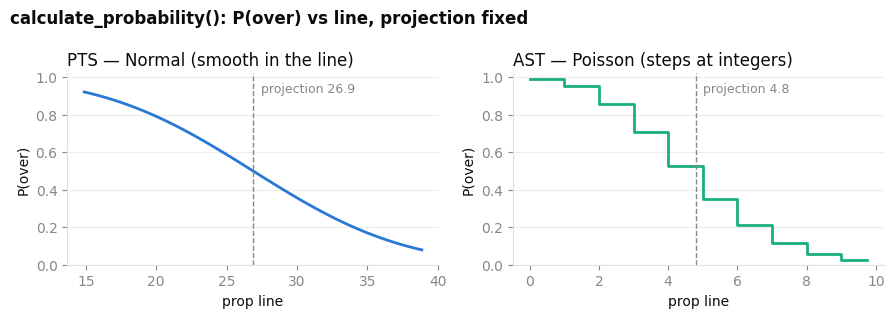

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.2))

lines_pts = np.arange(proj - 12, proj + 12.1, 0.5)
axes[0].plot(lines_pts, [calculate_probability("pts", proj, L, std) for L in lines_pts],
             color=BLUE, linewidth=2)
axes[0].axvline(proj, color=MUTED, linewidth=1, linestyle="--")
axes[0].annotate(f"projection {proj:.1f}", (proj, 0.97), color=MUTED, fontsize=9,
                 ha="left", xytext=(proj + 0.6, 0.92))
axes[0].set_title("PTS — Normal (smooth in the line)", loc="left", color=INK)

lines_ast = np.arange(max(ast_proj - 5, 0), ast_proj + 5.1, 0.25)
axes[1].plot(lines_ast, [calculate_probability("ast", ast_proj, L) for L in lines_ast],
             color=AQUA, linewidth=2, drawstyle="steps-post")
axes[1].axvline(ast_proj, color=MUTED, linewidth=1, linestyle="--")
axes[1].annotate(f"projection {ast_proj:.1f}", (ast_proj, 0.97), color=MUTED, fontsize=9,
                 ha="left", xytext=(ast_proj + 0.2, 0.92))
axes[1].set_title("AST — Poisson (steps at integers)", loc="left", color=INK)

for ax in axes:
    ax.set_xlabel("prop line")
    ax.set_ylabel("P(over)")
    ax.set_ylim(0, 1.02)
    ax.grid(axis="y", alpha=0.6)
    ax.set_axisbelow(True)
fig.suptitle("calculate_probability(): P(over) vs line, projection fixed",
             x=0.01, ha="left", color=INK, fontweight="bold")
plt.tight_layout()
plt.show()

The Poisson curve's staircase is the point: for a count stat, only the integer
threshold below the line matters — a 7.5 and a 7.9 assist line are the same bet.
The clamp is visible at both tails: the curves flatten at 0.01 / 0.99 instead of
asserting certainty.

## 6. Backtest-style evaluation + the four validation tests

We now replay the model over the test slice for one star player, following the
conventions of `services/backtest.py`:

- **Synthetic line** = the player's own L5 rolling average (real sportsbook lines
  aren't stored — this caveat matters and is repeated below).
- **Push voiding**: if the actual lands exactly on the line, a sportsbook voids
  the bet, so the game is excluded.
- A pick is **correct** when `(projection > line) == (actual > line)`;
  **edge** = |projection − line| in stat units.

Then the four tests from `services/statistical_validation.py`, inline with scipy.

In [13]:
# Replay the model over the featured player's test-slice games (selected in §5).
star["projection"] = model.predict(xgb.DMatrix(
    star[FEATURE_COLUMNS["pts"]].values.astype(np.float32),
    feature_names=FEATURE_COLUMNS["pts"]))
star["line"] = star["pts_L5"]                                   # synthetic L5 line
star = star[star["points"] != star["line"]]                     # void pushes
star["predicted_over"] = star["projection"] > star["line"]
star["correct"] = star["predicted_over"] == (star["points"] > star["line"])
star["error"] = star["points"] - star["projection"]             # actual − projection
star["edge"] = (star["projection"] - star["line"]).abs()
star["prob_over"] = [
    calculate_probability("pts", p, l, s)
    for p, l, s in zip(star["projection"], star["line"], star["pts_std_L10"])]

n = len(star)
hits = int(star["correct"].sum())
print(f"After push voiding: n={n}, hits={hits} ({hits / n:.1%})")
star[["date", "points", "line", "projection", "prob_over",
      "predicted_over", "correct", "edge"]].head(6)

After push voiding: n=46, hits=21 (45.7%)


,date,points,line,projection,prob_over,predicted_over,correct,edge
146,2025-02-12,32.0,34.4,29.847725,0.332927,False,True,4.552275
282,2025-02-13,24.0,34.0,29.960699,0.323577,False,True,4.039301
561,2025-02-21,21.0,28.8,33.608231,0.694703,True,False,4.808231
757,2025-02-23,37.0,28.0,29.963411,0.575310,True,True,1.963411
1059,2025-02-24,39.0,29.0,30.416603,0.569185,True,True,1.416603
1312,2025-02-26,27.0,30.6,29.790871,0.461615,False,True,0.809129


### The four validation tests

Constants come from `statistical_validation.py`: `BREAK_EVEN = 0.524` (the
win rate needed to profit at standard −110 two-way pricing), `MIN_N_RELIABLE = 30`,
`MIN_N_EDGE = 15`.

1. **Hit-rate significance** — one-sided binomial. *H₀: the true hit probability is
   ≤ 52.4%.* A small p-value says the observed hit rate would be surprising under
   coin-flip-at-break-even behavior. **Caveats:** the line is synthetic (beating
   your own L5 average is not beating a bookmaker), and games are treated as iid.
2. **Edge–hit correlation** — one-sided Spearman between |projection − line| and
   correctness. *H₀: larger edges are not associated with more hits.* One-sided to
   match the directional claim, exactly as the service does. **Caveat:** a rank
   correlation on a binary outcome over ~30 games is a coarse instrument.
3. **Calibration / bias** — one-sample t-test of the signed errors. *H₀: mean signed
   error = 0.* Significance means the model systematically over- or under-projects
   this player. **Caveat:** *absence of evidence is not evidence of absence* — at
   small n the test has little power, so "no detectable bias" ≠ "no bias".
4. **Sample adequacy** — no p-value, just gates: results below 30 games are flagged
   low-confidence; the edge correlation is skipped below 15.

In [14]:
BREAK_EVEN, MIN_N_RELIABLE, MIN_N_EDGE = 0.524, 30, 15   # statistical_validation.py

# 1 — Hit rate vs break-even (one-sided binomial)
hr = binomtest(hits, n, BREAK_EVEN, alternative="greater")
print(f"1. Hit rate       : {hits}/{n} = {hits / n:.1%}  vs 52.4% break-even")
print(f"   one-sided binomial p = {hr.pvalue:.4f}  → "
      f"{'significant' if hr.pvalue < 0.05 else 'NOT significant — plausibly noise'}")

# 2 — Edge–hit correlation (one-sided Spearman), gated on MIN_N_EDGE
if n >= MIN_N_EDGE:
    rho, p_edge = spearmanr(star["edge"], star["correct"].astype(int),
                            alternative="greater")
    print(f"\n2. Edge–hit corr  : Spearman ρ = {rho:+.3f}, one-sided p = {p_edge:.4f}")
    print(f"   → {'larger edges did hit more often here' if p_edge < 0.05 else 'edge size does NOT reliably predict outcomes in this sample'}")
else:
    print(f"\n2. Edge–hit corr  : skipped (n={n} < {MIN_N_EDGE})")

# 3 — Bias t-test on signed errors
tstat, p_bias = ttest_1samp(star["error"], popmean=0.0)
mean_err = float(star["error"].mean())
direction = ("negligible" if abs(mean_err) < 0.3
             else "under-projects" if mean_err > 0 else "over-projects")
print(f"\n3. Calibration    : mean signed error = {mean_err:+.2f} pts "
      f"(t = {tstat:+.2f}, two-sided p = {p_bias:.4f})")
print(f"   → {'systematic ' + direction + ' bias' if p_bias < 0.05 else 'no DETECTABLE bias — which is not proof of none'}")

# 4 — Sample adequacy gates
print(f"\n4. Sample adequacy: n = {n} "
      f"({'adequate' if n >= MIN_N_RELIABLE else 'LOW-CONFIDENCE'}; "
      f"threshold {MIN_N_RELIABLE}); "
      f"high-edge (≥2 pts) games: {int((star['edge'] >= 2).sum())}")

1. Hit rate       : 21/46 = 45.7%  vs 52.4% break-even
   one-sided binomial p = 0.8563  → NOT significant — plausibly noise

2. Edge–hit corr  : Spearman ρ = +0.156, one-sided p = 0.1500
   → edge size does NOT reliably predict outcomes in this sample

3. Calibration    : mean signed error = +2.09 pts (t = +1.74, two-sided p = 0.0895)
   → no DETECTABLE bias — which is not proof of none

4. Sample adequacy: n = 46 (adequate; threshold 30); high-edge (≥2 pts) games: 32


## 7. Caveats — read these before believing anything above

These limitations are standing disclosures, not footnotes (the production service
attaches them to every validation payload — see `DISCLOSURES` in
`statistical_validation.py`; the long-form treatment is in
[`docs/METHODOLOGY.md`](../docs/METHODOLOGY.md)):

1. **Synthetic lines.** The backtest line is the player's own L5 average, not a
   sportsbook line. Sportsbook lines embed injury news, lineup changes, and sharp
   money. Beating the 52.4% break-even against an L5 line does **not** imply
   profitability against real books.
2. **Selection bias.** The product roster is ~18 hand-picked durable stars, and this
   notebook features one of them. Results describe those players; they do not
   generalize to the league, and aggregating over a hand-picked roster overstates
   how well "the model" works.
3. **Multiple comparisons.** Run the four-test panel across ~18 players × 3 stats
   (~54 uncorrected panels) and at α = 0.05 a few "significant" results are expected
   by chance alone. Any single significant panel — including the one above — is
   descriptive, not portfolio-level evidence.
4. **Independence is assumed, not true.** The binomial and t-tests treat a player's
   games as iid draws. Streaks, schedule effects, blowouts, and lineup changes
   introduce serial dependence that nominal p-values ignore.
5. **Small-scale caveat for this notebook.** Two seasons of data and one test slice —
   the production models train on 2016-present and are evaluated season-by-season
   (`research/walk_forward_eval.py`). Numbers here illustrate the method, not the
   deployed model's exact performance.

**The one-sentence takeaway:** most of the "skill" a sloppy evaluation reports is
leakage and evaluation design, and the honest edge that survives `shift(1)` and a
chronological split is small — which is why this project ships with its validation
tests and its disclosures attached.

In [15]:
print("Headline numbers")
print(f"  Leakage demo : leaky MAE {leaky_mae:.2f}  vs honest MAE {honest_mae:.2f}")
print(f"  Split demo   : random {random_mae:.2f} vs chronological {honest_mae:.2f}")
print(f"  Final model  : XGBoost {model_mae:.2f} vs naive L5 {naive_mae:.2f} "
      f"({(1 - model_mae / naive_mae) * 100:.1f}% better)")
print(f"\nTotal runtime: {time.time() - T0:.1f}s")

Headline numbers
  Leakage demo : leaky MAE 2.43  vs honest MAE 5.03
  Split demo   : random 4.92 vs chronological 5.03
  Final model  : XGBoost 5.03 vs naive L5 5.36 (6.1% better)

Total runtime: 11.8s
